# ResNet18 R-band Five-Class Experiment — 20 Epochs

This code can also be used for other spectral bands. To do so, replace ROOT_DIR = "./Base_Donnees_Labo/R" with the appropriate subfolder for your target band (e.g., B, G, RE, Nir, or RGB). Additionally, you can update the parameter R_BAND_CODE = "3" to any value from 0 to 5, depending on the required band.

Note: This code was polished with the assistance of ChatGPT and checked by authors.

## Imports

In [3]:
import os
import re
import random
import numpy as np
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

import matplotlib.pyplot as plt
import seaborn as sns

## Parameters

In [5]:
# Folder containing the Red-band images
ROOT_DIR = "./Base_Donnees_Labo/R"

# In filename YYBCIIDQ, Red band is B = 3
R_BAND_CODE = "3"

# Years 21, 22, and 23:
# 80% training and 20% Test1
TRAIN_TEST1_YEARS = ["21", "22", "23"]

# Year 24:
# all selected images are used as Test2
TEST2_YEAR = "24"

# Only confirmed labels
Q_LABEL = "1"

# Five classes
CLASS_MAP = {
    "J": 0,
    "T": 1,
    "D": 2,
    "E": 3,
    "S": 4,
}

CLASS_NAMES = ["J", "T", "D", "E", "S"]

OUTPUT_DIR = (
    "Results_Years21_22_23_TrainTest1_"
    "Year24_Test2_RBand_5Classes_ResNet18_Last8Layers"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

SEED = 2024

IMG_SIZE = 224

BATCH_SIZE = 32

EPOCHS = 20

NUM_WORKERS = 0


# Piecewise learning-rate schedule
# Epochs  1-10: 1e-3
# Epochs 11-20: 5e-4
# Epochs 21-30: 1e-4
# Epochs 31-50: 5e-5
LR_STAGE_1 = 1e-3
LR_STAGE_2 = 5e-4
LR_STAGE_3 = 1e-4
LR_STAGE_4 = 5e-5


# Fine-tune the final 8 parameterized leaf modules
LAST_N_PARAMETER_LAYERS = 8


IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
)

## Reproducibility

In [7]:
random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)


torch.backends.cudnn.deterministic = True

torch.backends.cudnn.benchmark = False


# Keep fixed seeds and deterministic cuDNN behavior without forcing
# strict CUDA determinism, avoiding the CuBLAS backward error.
torch.use_deterministic_algorithms(False)


print(
    "Strict deterministic algorithms enabled:",
    torch.are_deterministic_algorithms_enabled()
)

Strict deterministic algorithms enabled: False


## Filename parser

In [9]:
"""
Filename format:

YYBCIIDQ

YY : year
B  : band
C  : class
I  : illumination
ID : four-digit image ID
Q  : label confirmation

Example:

243J012341

24   = year
3    = Red band
J    = class
0    = illumination
1234 = image ID
1    = confirmed label
"""


pattern = re.compile(
    r"^(\d{2})(\d)([A-Za-z])([A-Za-z0-9])(\d{4})(\d)$"
)

## Read Red-band images

In [11]:
records = []


if not os.path.isdir(ROOT_DIR):

    raise FileNotFoundError(
        f"Image folder not found: {ROOT_DIR}"
    )


selected_years = TRAIN_TEST1_YEARS + [TEST2_YEAR]


for root, directories, files in os.walk(ROOT_DIR):

    directories.sort()

    files.sort()

    for file in files:

        if not file.lower().endswith(IMAGE_EXTENSIONS):

            continue

        name = os.path.splitext(file)[0]

        match = pattern.match(name)

        if match is None:

            continue


        year = match.group(1)

        band = match.group(2)

        cls = match.group(3).upper()

        illumination = match.group(4).upper()

        image_id = match.group(5)

        q = match.group(6)


        ####################################################
        # Selection
        ####################################################

        if year not in selected_years:

            continue

        if band != R_BAND_CODE:

            continue

        if cls not in CLASS_MAP:

            continue

        # No illumination filtering is applied

        if q != Q_LABEL:

            continue


        image_path = os.path.join(
            root,
            file
        )


        # Different illumination versions of the same physical case
        # remain in the same subset because illumination is excluded.
        group_key = (
            f"{year}_{cls}_{image_id}_{q}"
        )


        # sample_key identifies one concrete image version
        sample_key = (
            f"{year}_{cls}_{illumination}_{image_id}_{q}"
        )


        records.append(
            {
                "path": image_path,
                "filename": file,
                "sample_key": sample_key,
                "group_key": group_key,
                "year": year,
                "band": band,
                "class": cls,
                "illumination": illumination,
                "image_id": image_id,
                "q": q,
                "label": CLASS_MAP[cls],
            }
        )


        # print(
        #     f"Read {file} | "
        #     f"Year={year} | "
        #     f"Class={cls} | "
        #     f"Illumination={illumination} | "
        #     f"ID={image_id} | "
        #     f"Label={CLASS_MAP[cls]}"
        # )

## DataFrame

In [13]:
df = pd.DataFrame(
    records
)


if df.empty:

    raise RuntimeError(
        "No Red-band five-class images were selected. "
        "Check ROOT_DIR, filename format, R_BAND_CODE, and Q_LABEL."
    )


df = df.sort_values(
    by=[
        "year",
        "class",
        "image_id",
        "illumination",
        "filename",
    ]
).reset_index(drop=True)


# Check duplicate file paths
if df["path"].duplicated().any():

    duplicated_paths = df[
        df["path"].duplicated(
            keep=False
        )
    ]

    duplicated_paths.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "duplicated_image_paths.csv"
        ),
        index=False
    )

    raise RuntimeError(
        "Duplicate image paths were found. "
        "See duplicated_image_paths.csv."
    )


df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "all_selected_Rband_5Classes_images.csv"
    ),
    index=False
)


print("\n" + "=" * 70)

print(
    "Total selected Red-band five-class images:",
    len(df)
)

print("=" * 70)


print("\nYear count")

print(
    df["year"].value_counts().sort_index()
)


print("\nClass count")

print(
    df["class"].value_counts().sort_index()
)


print("\nYear and class count")

print(
    pd.crosstab(
        df["year"],
        df["class"]
    )
)


print("\nIllumination count")

print(
    df["illumination"].value_counts().sort_index()
)


Total selected Red-band five-class images: 10878

Year count
year
21    2607
22    3598
23    2029
24    2644
Name: count, dtype: int64

Class count
class
D    1510
E    2457
J    1781
S    2354
T    2776
Name: count, dtype: int64

Year and class count
class    D    E    J    S    T
year                          
21       0  852  299  625  831
22     756  710  558  708  866
23     400  437  319  434  439
24     354  458  605  587  640

Illumination count
illumination
0    7000
2    2532
D     671
G     675
Name: count, dtype: int64


## Plot one confirmed Red-band sample from each class

Displayed sample: 213J009441.tif | True class: J | Q: 1 | Year: 21 | Illumination: 0
Displayed sample: 213T020511.tif | True class: T | Q: 1 | Year: 21 | Illumination: 0
Displayed sample: 223D000001.tif | True class: D | Q: 1 | Year: 22 | Illumination: 0
Displayed sample: 213E000001.tif | True class: E | Q: 1 | Year: 21 | Illumination: 0
Displayed sample: 213S214191.tif | True class: S | Q: 1 | Year: 21 | Illumination: 2


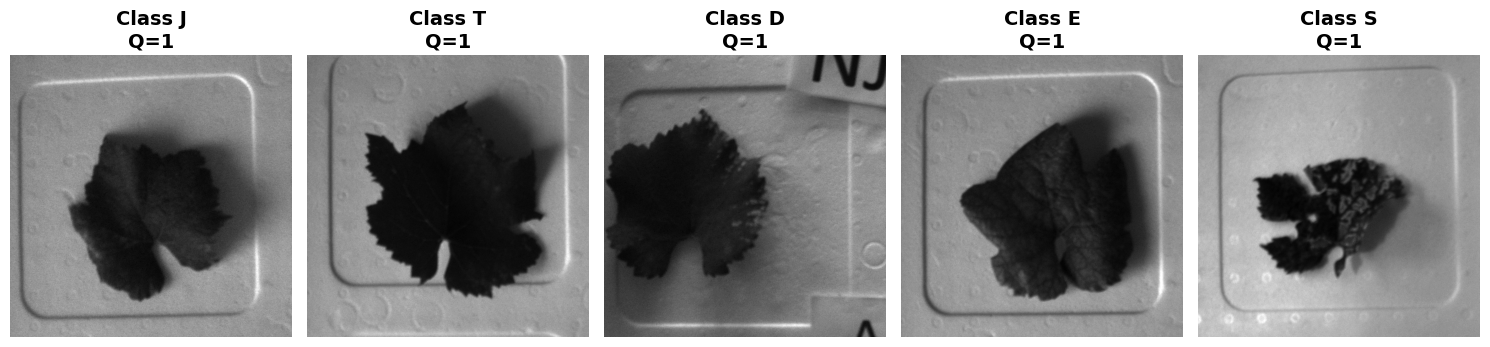

In [15]:
# All images in df already satisfy Q_LABEL == "1".
# Select one deterministic example from each of the five classes.
# The displayed image is the actual single-band Red image after
# the same per-image min-max mapping to [0,255] used later by
# the network input pipeline.

sample_records = []


for class_name in CLASS_NAMES:

    class_df = df[
        df["class"] == class_name
    ].sort_values(
        by=[
            "year",
            "image_id",
            "illumination",
            "filename",
        ]
    ).reset_index(drop=True)


    if class_df.empty:

        raise RuntimeError(
            f"No confirmed Q=1 Red-band sample is available "
            f"for class {class_name}."
        )


    sample_records.append(
        class_df.iloc[0]
    )


sample_figure, sample_axes = plt.subplots(
    1,
    len(CLASS_NAMES),
    figsize=(15, 3.4)
)


for axis_index, sample_row in enumerate(
    sample_records
):

    with Image.open(
        sample_row["path"]
    ) as sample_source_image:

        sample_array = np.asarray(
            sample_source_image.convert("F"),
            dtype=np.float32
        )


    finite_mask = np.isfinite(
        sample_array
    )


    if not finite_mask.any():

        raise RuntimeError(
            f"Sample image contains no finite values: "
            f"{sample_row['filename']}"
        )


    valid_values = sample_array[
        finite_mask
    ]


    minimum_value = float(
        valid_values.min()
    )


    maximum_value = float(
        valid_values.max()
    )


    if maximum_value > minimum_value:

        display_array = (
            (
                sample_array
                - minimum_value
            )
            /
            (
                maximum_value
                - minimum_value
            )
        )

    else:

        display_array = np.zeros_like(
            sample_array,
            dtype=np.float32
        )


    display_array = np.nan_to_num(
        display_array,
        nan=0.0,
        posinf=1.0,
        neginf=0.0
    )


    display_array = np.clip(
        display_array,
        0.0,
        1.0
    )


    sample_axes[
        axis_index
    ].imshow(
        display_array,
        cmap="gray",
        vmin=0.0,
        vmax=1.0
    )


    sample_axes[
        axis_index
    ].set_title(
        f"Class {sample_row['class']}\n"
        f"Q={sample_row['q']}",
        fontsize=14,
        fontweight="bold"
    )


    sample_axes[
        axis_index
    ].axis(
        "off"
    )


    print(
        "Displayed sample:",
        sample_row["filename"],
        "| True class:",
        sample_row["class"],
        "| Q:",
        sample_row["q"],
        "| Year:",
        sample_row["year"],
        "| Illumination:",
        sample_row["illumination"]
    )


sample_figure.tight_layout()


sample_figure.savefig(
    os.path.join(
        OUTPUT_DIR,
        "Five_RBand_Q1_Class_Samples.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)


plt.show()


plt.close(
    sample_figure
)

## Prepare Year 21-23 and Year 24 datasets

In [17]:
development_df = df[
    df["year"].isin(
        TRAIN_TEST1_YEARS
    )
].reset_index(drop=True)


test2_df = df[
    df["year"] == TEST2_YEAR
].reset_index(drop=True)


if development_df.empty:

    raise RuntimeError(
        "No Year 21-23 images were found."
    )


if test2_df.empty:

    raise RuntimeError(
        "No Year 24 images were found."
    )

## Group-level 80%/20% split without data leakage

In [19]:
# Split unique physical-case groups first, then expand back to images.
development_group_df = (
    development_df[
        [
            "group_key",
            "year",
            "class",
            "label",
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)


# Each group must correspond to one class only
group_class_counts = (
    development_df
    .groupby("group_key")["class"]
    .nunique()
)


if (group_class_counts > 1).any():

    invalid_groups = group_class_counts[
        group_class_counts > 1
    ]

    invalid_groups.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "invalid_groups_with_multiple_classes.csv"
        ),
        header=["number_of_classes"]
    )

    raise RuntimeError(
        "Some group keys contain more than one class. "
        "See invalid_groups_with_multiple_classes.csv."
    )


# Ensure all five classes are available in Years 21-23
missing_development_classes = [
    class_name
    for class_name in CLASS_NAMES
    if class_name not in development_group_df["class"].unique()
]


if missing_development_classes:

    raise RuntimeError(
        "Years 21-23 do not contain all five classes. "
        f"Missing classes: {missing_development_classes}"
    )


# Joint year-class stratification preserves both year and class
# composition in the 80% training and 20% Test1 subsets.
development_group_df["year_class"] = (
    development_group_df["year"].astype(str)
    + "_"
    + development_group_df["class"].astype(str)
)


year_class_counts = (
    development_group_df["year_class"]
    .value_counts()
)


if (year_class_counts < 2).any():

    raise RuntimeError(
        "Each year-class group must contain at least two unique "
        "physical groups for stratified 80/20 splitting.\n"
        f"{year_class_counts}"
    )


train_group_df, test1_group_df = train_test_split(
    development_group_df,
    test_size=0.2,
    random_state=SEED,
    stratify=development_group_df["year_class"],
    shuffle=True,
)


train_group_df = train_group_df.drop(
    columns=["year_class"]
).reset_index(drop=True)


test1_group_df = test1_group_df.drop(
    columns=["year_class"]
).reset_index(drop=True)


train_group_keys = set(
    train_group_df["group_key"].tolist()
)


test1_group_keys = set(
    test1_group_df["group_key"].tolist()
)


train_df = development_df[
    development_df["group_key"].isin(
        train_group_keys
    )
].reset_index(drop=True)


test1_df = development_df[
    development_df["group_key"].isin(
        test1_group_keys
    )
].reset_index(drop=True)

## Explicit leakage checks

In [21]:
test2_group_keys = set(
    test2_df["group_key"].tolist()
)


assert train_group_keys.isdisjoint(
    test1_group_keys
), "Data leakage: Train and Test1 share group keys."


assert train_group_keys.isdisjoint(
    test2_group_keys
), "Data leakage: Train and Test2 share group keys."


assert test1_group_keys.isdisjoint(
    test2_group_keys
), "Data leakage: Test1 and Test2 share group keys."


train_sample_keys = set(
    train_df["sample_key"].tolist()
)


test1_sample_keys = set(
    test1_df["sample_key"].tolist()
)


test2_sample_keys = set(
    test2_df["sample_key"].tolist()
)


assert train_sample_keys.isdisjoint(
    test1_sample_keys
), "Data leakage: Train and Test1 share sample keys."


assert train_sample_keys.isdisjoint(
    test2_sample_keys
), "Data leakage: Train and Test2 share sample keys."


assert test1_sample_keys.isdisjoint(
    test2_sample_keys
), "Data leakage: Test1 and Test2 share sample keys."


train_paths = set(
    train_df["path"].tolist()
)


test1_paths = set(
    test1_df["path"].tolist()
)


test2_paths = set(
    test2_df["path"].tolist()
)


assert train_paths.isdisjoint(
    test1_paths
), "Data leakage: Train and Test1 share image paths."


assert train_paths.isdisjoint(
    test2_paths
), "Data leakage: Train and Test2 share image paths."


assert test1_paths.isdisjoint(
    test2_paths
), "Data leakage: Test1 and Test2 share image paths."


assert (
    len(train_df)
    + len(test1_df)
    == len(development_df)
), "Some Year 21-23 images were lost or duplicated during splitting."


print("\nData leakage check: PASSED")


Data leakage check: PASSED


## Save dataset splits

In [23]:
print("\nDataset split")

print("-" * 70)

print(
    "Training images, Years 21-23:",
    len(train_df)
)

print(
    "Test1 images, Years 21-23:",
    len(test1_df)
)

print(
    "Test2 images, Year 24:",
    len(test2_df)
)

print("-" * 70)


print("\nTraining year and class count")

print(
    pd.crosstab(
        train_df["year"],
        train_df["class"]
    )
)


print("\nTest1 year and class count")

print(
    pd.crosstab(
        test1_df["year"],
        test1_df["class"]
    )
)


print("\nTest2 class count")

print(
    test2_df["class"].value_counts().sort_index()
)


train_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "train_years21_22_23_Rband_80_percent.csv"
    ),
    index=False
)


test1_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "test1_years21_22_23_Rband_20_percent.csv"
    ),
    index=False
)


test2_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "test2_year24_Rband.csv"
    ),
    index=False
)


train_group_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "train_group_keys.csv"
    ),
    index=False
)


test1_group_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "test1_group_keys.csv"
    ),
    index=False
)


Dataset split
----------------------------------------------------------------------
Training images, Years 21-23: 6587
Test1 images, Years 21-23: 1647
Test2 images, Year 24: 2644
----------------------------------------------------------------------

Training year and class count
class    D    E    J    S    T
year                          
21       0  682  239  500  665
22     605  568  446  566  693
23     320  350  255  347  351

Test1 year and class count
class    D    E    J    S    T
year                          
21       0  170   60  125  166
22     151  142  112  142  173
23      80   87   64   87   88

Test2 class count
class
D    354
E    458
J    605
S    587
T    640
Name: count, dtype: int64


## Image processing

In [25]:
weights = ResNet18_Weights.DEFAULT


imagenet_mean = weights.transforms().mean

imagenet_std = weights.transforms().std


resize_to_224 = transforms.Resize(
    (IMG_SIZE, IMG_SIZE),
    interpolation=transforms.InterpolationMode.BILINEAR,
    antialias=True,
)


imagenet_normalize = transforms.Normalize(
    mean=imagenet_mean,
    std=imagenet_std
)


def normalize_R_band_to_uint8(image):
    """
    Per-image min-max normalization of one Red-band image to uint8
    values in the range [0, 255].

    This transformation uses only the current image and therefore
    does not use test-set information for training-image processing.
    """

    image_array = np.asarray(
        image.convert("F"),
        dtype=np.float32
    )


    finite_mask = np.isfinite(
        image_array
    )


    if not finite_mask.any():

        raise RuntimeError(
            "Image contains no finite pixel values."
        )


    valid_values = image_array[
        finite_mask
    ]


    minimum_value = float(
        valid_values.min()
    )


    maximum_value = float(
        valid_values.max()
    )


    if maximum_value > minimum_value:

        normalized_array = (
            (
                image_array
                - minimum_value
            )
            /
            (
                maximum_value
                - minimum_value
            )
            * 255.0
        )

    else:

        normalized_array = np.zeros_like(
            image_array,
            dtype=np.float32
        )


    normalized_array = np.nan_to_num(
        normalized_array,
        nan=0.0,
        posinf=255.0,
        neginf=0.0
    )


    normalized_array = np.clip(
        normalized_array,
        0.0,
        255.0
    ).astype(np.uint8)


    return Image.fromarray(
        normalized_array,
        mode="L"
    )

## Dataset

In [27]:
class ImageDataset(Dataset):

    def __init__(
        self,
        dataframe,
        resize_transform,
        normalize_transform
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.resize_transform = resize_transform

        self.normalize_transform = normalize_transform


    def __len__(self):

        return len(
            self.df
        )


    def __getitem__(self, index):

        row = self.df.iloc[
            index
        ]


        with Image.open(
            row["path"]
        ) as source_image:

            # 1. Normalize the Red band to [0, 255]
            image_R = normalize_R_band_to_uint8(
                source_image
            )


        # 2. Copy the normalized Red band into three identical
        #    channels, creating an RGB-format image
        image_RGB = image_R.convert(
            "RGB"
        )


        # 3. Resize the three-channel image to 224 x 224
        image_RGB = self.resize_transform(
            image_RGB
        )


        # 4. Convert the uint8 RGB image from [0,255] to a tensor [0,1]
        image_tensor = transforms.functional.to_tensor(
            image_RGB
        )


        # 5. Apply ImageNet normalization
        image_tensor = self.normalize_transform(
            image_tensor
        )


        label = torch.tensor(
            row["label"],
            dtype=torch.long
        )


        return image_tensor, label


train_dataset = ImageDataset(
    train_df,
    resize_to_224,
    imagenet_normalize
)


test1_dataset = ImageDataset(
    test1_df,
    resize_to_224,
    imagenet_normalize
)


test2_dataset = ImageDataset(
    test2_df,
    resize_to_224,
    imagenet_normalize
)

## DataLoader

In [29]:
loader_generator = torch.Generator()

loader_generator.manual_seed(
    SEED
)


def seed_worker(worker_id):

    worker_seed = SEED + worker_id

    np.random.seed(
        worker_seed
    )

    random.seed(
        worker_seed
    )


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker,
    generator=loader_generator,
)


test1_loader = DataLoader(
    test1_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker,
)


test2_loader = DataLoader(
    test2_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker,
)

## GPU

In [31]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "Device:",
    device
)

Device: cuda


## ResNet18 with ImageNet weights

In [33]:
model = resnet18(
    weights=weights
)


# Replace ImageNet's 1000-class classifier with five-class output
model.fc = nn.Linear(
    model.fc.in_features,
    len(CLASS_NAMES)
)

## Fine-tune last 8 layers

In [35]:
# Freeze all parameters first
for parameter in model.parameters():

    parameter.requires_grad = False


parameterized_leaf_modules = []


for module_name, module in model.named_modules():

    has_children = any(
        True
        for _ in module.children()
    )


    direct_parameters = list(
        module.parameters(
            recurse=False
        )
    )


    if (
        not has_children
        and len(direct_parameters) > 0
    ):

        parameterized_leaf_modules.append(
            (
                module_name,
                module
            )
        )


if len(parameterized_leaf_modules) < LAST_N_PARAMETER_LAYERS:

    raise RuntimeError(
        "The model contains fewer parameterized leaf modules "
        f"than LAST_N_PARAMETER_LAYERS={LAST_N_PARAMETER_LAYERS}."
    )


fine_tuned_modules = parameterized_leaf_modules[
    -LAST_N_PARAMETER_LAYERS:
]


for module_name, module in fine_tuned_modules:

    for parameter in module.parameters(
        recurse=False
    ):

        parameter.requires_grad = True


# Ensure the new classifier is trainable
for parameter in model.fc.parameters():

    parameter.requires_grad = True


print(
    "\nFinal parameterized modules selected for fine-tuning:"
)


for module_name, _ in fine_tuned_modules:

    print(
        module_name
    )


Final parameterized modules selected for fine-tuning:
layer4.0.bn2
layer4.0.downsample.0
layer4.0.downsample.1
layer4.1.conv1
layer4.1.bn1
layer4.1.conv2
layer4.1.bn2
fc


## Save parameter configuration

In [37]:
parameter_records = []


for parameter_name, parameter in model.named_parameters():

    parameter_records.append(
        {
            "parameter_name": parameter_name,
            "requires_grad": parameter.requires_grad,
            "number_of_parameters": parameter.numel(),
        }
    )


parameter_df = pd.DataFrame(
    parameter_records
)


parameter_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "model_parameter_configuration.csv"
    ),
    index=False
)


fine_tuned_module_df = pd.DataFrame(
    {
        "fine_tuned_module": [
            module_name
            for module_name, _ in fine_tuned_modules
        ]
    }
)


fine_tuned_module_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "fine_tuned_last_8_modules.csv"
    ),
    index=False
)


total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)


trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)


frozen_parameters = (
    total_parameters
    - trainable_parameters
)


print(
    "\nTotal parameters:",
    total_parameters
)

print(
    "Trainable parameters:",
    trainable_parameters
)

print(
    "Frozen parameters:",
    frozen_parameters
)


model = model.to(
    device
)


Total parameters: 11179077
Trainable parameters: 4856325
Frozen parameters: 6322752


## Loss and optimizer

In [39]:
criterion = nn.CrossEntropyLoss()


optimizer = optim.Adam(
    filter(
        lambda parameter: parameter.requires_grad,
        model.parameters()
    ),
    lr=LR_STAGE_1
)


scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

## Learning-rate functions

In [41]:
def get_learning_rate(epoch_index):
    """
    epoch_index is zero-based:

      0-9   -> 1e-3
      10-19 -> 5e-4
      20-29 -> 1e-4
      30-49 -> 5e-5
    """

    if epoch_index < 10:

        return LR_STAGE_1

    if epoch_index < 20:

        return LR_STAGE_2

    if epoch_index < 30:

        return LR_STAGE_3

    return LR_STAGE_4


def set_optimizer_learning_rate(
    optimizer_object,
    learning_rate
):

    for parameter_group in optimizer_object.param_groups:

        parameter_group[
            "lr"
        ] = learning_rate


def set_frozen_batchnorm_to_eval(
    model_object
):
    """
    Keep frozen BatchNorm modules in evaluation mode so their
    running mean and variance are not updated during training.
    """

    for module in model_object.modules():

        if isinstance(
            module,
            nn.modules.batchnorm._BatchNorm
        ):

            module_parameters = list(
                module.parameters(
                    recurse=False
                )
            )

            if (
                len(module_parameters) > 0
                and not any(
                    parameter.requires_grad
                    for parameter in module_parameters
                )
            ):

                module.eval()

## Training

In [43]:
history = []

best_acc = -1.0

best_epoch = 0


for epoch in range(EPOCHS):

    current_lr = get_learning_rate(
        epoch
    )


    set_optimizer_learning_rate(
        optimizer,
        current_lr
    )


    model.train()


    set_frozen_batchnorm_to_eval(
        model
    )


    loss_sum = 0.0

    correct = 0

    total = 0


    for images, labels in train_loader:

        images = images.to(
            device,
            non_blocking=torch.cuda.is_available()
        )


        labels = labels.to(
            device,
            non_blocking=torch.cuda.is_available()
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        with torch.amp.autocast(
            device_type=device.type,
            enabled=torch.cuda.is_available()
        ):

            output = model(
                images
            )


            loss = criterion(
                output,
                labels
            )


        scaler.scale(
            loss
        ).backward()


        scaler.step(
            optimizer
        )


        scaler.update()


        loss_sum += (
            loss.item()
            * images.size(0)
        )


        prediction = output.argmax(
            dim=1
        )


        correct += (
            prediction == labels
        ).sum().item()


        total += labels.size(0)


    epoch_loss = (
        loss_sum
        / total
    )


    epoch_acc = (
        correct
        / total
    )


    print(
        f"Epoch {epoch + 1}/{EPOCHS} "
        f"LR={current_lr:.8f} "
        f"Loss={epoch_loss:.6f} "
        f"Accuracy={epoch_acc:.6f}"
    )


    history.append(
        {
            "Epoch": epoch + 1,
            "LearningRate": current_lr,
            "Loss": epoch_loss,
            "Accuracy": epoch_acc,
        }
    )


    # Test1 and Test2 are not used for model selection.
    if epoch_acc > best_acc:

        best_acc = epoch_acc

        best_epoch = epoch + 1


        torch.save(
            model.state_dict(),
            os.path.join(
                OUTPUT_DIR,
                "best_model_Rband_5Classes_last8layers.pth"
            )
        )

Epoch 1/20 LR=0.00100000 Loss=0.601106 Accuracy=0.777896
Epoch 2/20 LR=0.00100000 Loss=0.301419 Accuracy=0.893578
Epoch 3/20 LR=0.00100000 Loss=0.155456 Accuracy=0.946865
Epoch 4/20 LR=0.00100000 Loss=0.086830 Accuracy=0.969182
Epoch 5/20 LR=0.00100000 Loss=0.072135 Accuracy=0.972218
Epoch 6/20 LR=0.00100000 Loss=0.040692 Accuracy=0.988007
Epoch 7/20 LR=0.00100000 Loss=0.033683 Accuracy=0.989525
Epoch 8/20 LR=0.00100000 Loss=0.031415 Accuracy=0.990132
Epoch 9/20 LR=0.00100000 Loss=0.043166 Accuracy=0.984211
Epoch 10/20 LR=0.00100000 Loss=0.055643 Accuracy=0.980720
Epoch 11/20 LR=0.00050000 Loss=0.015327 Accuracy=0.994990
Epoch 12/20 LR=0.00050000 Loss=0.006738 Accuracy=0.998026
Epoch 13/20 LR=0.00050000 Loss=0.001974 Accuracy=1.000000
Epoch 14/20 LR=0.00050000 Loss=0.002363 Accuracy=0.999545
Epoch 15/20 LR=0.00050000 Loss=0.002566 Accuracy=0.999241
Epoch 16/20 LR=0.00050000 Loss=0.000831 Accuracy=1.000000
Epoch 17/20 LR=0.00050000 Loss=0.000606 Accuracy=1.000000
Epoch 18/20 LR=0.000500

## Save training history

In [45]:
history_df = pd.DataFrame(
    history
)


history_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "training_history.csv"
    ),
    index=False
)


print(
    "\nBest training epoch:",
    best_epoch
)

print(
    "Best training accuracy:",
    best_acc
)


Best training epoch: 13
Best training accuracy: 1.0


## Load best model

In [47]:
best_model_path = os.path.join(
    OUTPUT_DIR,
    "best_model_Rband_5Classes_last8layers.pth"
)


try:

    loaded_state_dict = torch.load(
        best_model_path,
        map_location=device,
        weights_only=True
    )

except TypeError:

    loaded_state_dict = torch.load(
        best_model_path,
        map_location=device
    )


model.load_state_dict(
    loaded_state_dict
)

<All keys matched successfully>

## Evaluation function

In [49]:
def evaluate(
    loader,
    dataframe,
    name
):

    if dataframe.empty:

        print(
            f"\n{name}: no samples available."
        )

        return


    model.eval()


    y_true = []

    y_pred = []

    all_probabilities = []


    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=torch.cuda.is_available()
            )


            output = model(
                images
            )


            probabilities = torch.softmax(
                output,
                dim=1
            )


            prediction = output.argmax(
                dim=1
            )


            y_true.extend(
                labels.numpy().tolist()
            )


            y_pred.extend(
                prediction.cpu().numpy().tolist()
            )


            all_probabilities.extend(
                probabilities.cpu().numpy().tolist()
            )


    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(
            range(
                len(CLASS_NAMES)
            )
        )
    )


    accuracy = accuracy_score(
        y_true,
        y_pred
    )


    macro_precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )


    macro_recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )


    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )


    metrics_df = pd.DataFrame(
        {
            "Accuracy": [
                accuracy
            ],
            "MacroPrecision": [
                macro_precision
            ],
            "MacroRecall": [
                macro_recall
            ],
            "MacroF1": [
                macro_f1
            ],
            "NumberOfImages": [
                len(y_true)
            ],
            "NumberOfGroups": [
                dataframe["group_key"].nunique()
            ],
        }
    )


    print("\n" + "=" * 70)

    print(name)

    print("=" * 70)

    print(
        metrics_df
    )


    print(
        f"Accuracy: {accuracy:.6f}"
    )


    print(
        f"Macro Precision: {macro_precision:.6f}"
    )


    print(
        f"Macro Recall: {macro_recall:.6f}"
    )


    print(
        f"Macro F1 score: {macro_f1:.6f}"
    )


    print("\nConfusion matrix (counts)")

    print(
        cm
    )


    metrics_df.to_csv(
        os.path.join(
            OUTPUT_DIR,
            name + "_metrics.csv"
        ),
        index=False
    )


    report_dict = classification_report(
        y_true,
        y_pred,
        labels=list(
            range(
                len(CLASS_NAMES)
            )
        ),
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )


    report_df = pd.DataFrame(
        report_dict
    ).transpose()


    report_df.to_csv(
        os.path.join(
            OUTPUT_DIR,
            name + "_classification_report.csv"
        )
    )


    confusion_matrix_df = pd.DataFrame(
        cm,
        index=[
            f"True_{class_name}"
            for class_name in CLASS_NAMES
        ],
        columns=[
            f"Predicted_{class_name}"
            for class_name in CLASS_NAMES
        ]
    )


    confusion_matrix_df.to_csv(
        os.path.join(
            OUTPUT_DIR,
            name + "_confusion_matrix.csv"
        )
    )


    prediction_df = dataframe.copy().reset_index(
        drop=True
    )


    prediction_df[
        "ground_truth_label"
    ] = y_true


    prediction_df[
        "predicted_label"
    ] = y_pred


    label_to_class = {
        value: key
        for key, value in CLASS_MAP.items()
    }


    prediction_df[
        "ground_truth_class"
    ] = prediction_df[
        "ground_truth_label"
    ].map(
        label_to_class
    )


    prediction_df[
        "predicted_class"
    ] = prediction_df[
        "predicted_label"
    ].map(
        label_to_class
    )


    probability_array = np.asarray(
        all_probabilities,
        dtype=np.float32
    )


    for class_index, class_name in enumerate(
        CLASS_NAMES
    ):

        prediction_df[
            f"probability_{class_name}"
        ] = probability_array[
            :,
            class_index
        ]


    prediction_df.to_csv(
        os.path.join(
            OUTPUT_DIR,
            name + "_predictions.csv"
        ),
        index=False
    )


    ########################################################
    # Row-normalized percentage confusion matrix
    ########################################################

    row_sums = cm.sum(
        axis=1,
        keepdims=True
    )


    normalized_cm = np.divide(
        cm.astype(
            np.float64
        ),
        row_sums,
        out=np.zeros_like(
            cm,
            dtype=np.float64
        ),
        where=row_sums != 0
    )


    percentage_cm = (
        normalized_cm
        *
        100.0
    )


    normalized_confusion_matrix_df = pd.DataFrame(
        normalized_cm,
        index=[
            f"True_{class_name}"
            for class_name in CLASS_NAMES
        ],
        columns=[
            f"Predicted_{class_name}"
            for class_name in CLASS_NAMES
        ]
    )


    normalized_confusion_matrix_df.to_csv(
        os.path.join(
            OUTPUT_DIR,
            name
            +
            "_normalized_confusion_matrix_0_to_1.csv"
        )
    )


    percentage_confusion_matrix_df = pd.DataFrame(
        percentage_cm,
        index=[
            f"True_{class_name}"
            for class_name in CLASS_NAMES
        ],
        columns=[
            f"Predicted_{class_name}"
            for class_name in CLASS_NAMES
        ]
    )


    percentage_confusion_matrix_df.to_csv(
        os.path.join(
            OUTPUT_DIR,
            name
            +
            "_normalized_confusion_matrix_percent.csv"
        )
    )


    print(
        "\nRow-normalized confusion matrix (0-1)"
    )


    print(
        normalized_confusion_matrix_df
    )


    ########################################################
    # Plot five-class normalized percentage confusion matrix
    ########################################################

    from mpl_toolkits.axes_grid1 import make_axes_locatable


    plt.rcParams.update(
        {
            "font.family": "Times New Roman",
            "font.size": 18,
            "axes.labelsize": 22,
            "axes.titlesize": 22,
            "xtick.labelsize": 18,
            "ytick.labelsize": 18,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        }
    )


    cm_figure = plt.figure(
        figsize=(
            7.0,
            6.2
        )
    )


    cm_axis = cm_figure.add_axes(
        [
            0.16,
            0.16,
            0.66,
            0.66,
        ]
    )


    cm_axis.set_box_aspect(
        1
    )


    cm_image = cm_axis.imshow(
        percentage_cm,
        interpolation="nearest",
        cmap="Greens",
        vmin=0.0,
        vmax=100.0,
        aspect="equal",
        origin="upper"
    )


    divider = make_axes_locatable(
        cm_axis
    )


    colorbar_axis = divider.append_axes(
        "right",
        size="6%",
        pad=0.12
    )


    colorbar = cm_figure.colorbar(
        cm_image,
        cax=colorbar_axis
    )


    colorbar.set_ticks(
        [
            0,
            20,
            40,
            60,
            80,
            100,
        ]
    )


    colorbar.set_ticklabels(
        [
            "0%",
            "20%",
            "40%",
            "60%",
            "80%",
            "100%",
        ]
    )


    colorbar.ax.tick_params(
        labelsize=17,
        width=0.8,
        length=4
    )


    colorbar.outline.set_linewidth(
        1.0
    )


    cm_axis.set_xticks(
        np.arange(
            len(
                CLASS_NAMES
            )
        )
    )


    cm_axis.set_yticks(
        np.arange(
            len(
                CLASS_NAMES
            )
        )
    )


    cm_axis.set_xticklabels(
        CLASS_NAMES
    )


    cm_axis.set_yticklabels(
        CLASS_NAMES
    )


    cm_axis.set_xlabel(
        "Predicted class",
        fontweight="bold",
        labelpad=10
    )


    cm_axis.set_ylabel(
        "True class",
        fontweight="bold",
        labelpad=10
    )


    cm_axis.set_title(
        ""
    )


    cm_axis.tick_params(
        axis="both",
        which="major",
        length=0,
        pad=7
    )


    cm_axis.set_xticks(
        np.arange(
            -0.5,
            len(
                CLASS_NAMES
            ),
            1
        ),
        minor=True
    )


    cm_axis.set_yticks(
        np.arange(
            -0.5,
            len(
                CLASS_NAMES
            ),
            1
        ),
        minor=True
    )


    cm_axis.grid(
        which="minor",
        color="black",
        linestyle="-",
        linewidth=1.2,
        alpha=0.85
    )


    cm_axis.tick_params(
        which="minor",
        bottom=False,
        left=False
    )


    for row_index in range(
        percentage_cm.shape[0]
    ):

        for column_index in range(
            percentage_cm.shape[1]
        ):

            percentage = percentage_cm[
                row_index,
                column_index
            ]


            text_color = (
                "white"
                if percentage >= 40.0
                else "black"
            )


            cm_axis.text(
                column_index,
                row_index,
                f"{percentage:.1f}%",
                ha="center",
                va="center",
                color=text_color,
                fontsize=15,
                fontweight="bold"
            )


    for spine in cm_axis.spines.values():

        spine.set_visible(
            True
        )

        spine.set_linewidth(
            1.5
        )

        spine.set_color(
            "black"
        )


    cm_figure.savefig(
        os.path.join(
            OUTPUT_DIR,
            name
            +
            "_Normalized_CM_Percentage.png"
        ),
        dpi=600,
        facecolor="white"
    )


    cm_figure.savefig(
        os.path.join(
            OUTPUT_DIR,
            name
            +
            "_Normalized_CM_Percentage.pdf"
        ),
        facecolor="white"
    )


    plt.show()


    plt.close(
        cm_figure
    )


## Evaluate Test1 and Test2


Test1_Years21_22_23_Rband_5Classes
   Accuracy  MacroPrecision  MacroRecall   MacroF1  NumberOfImages  \
0  0.925319        0.922097      0.91639  0.918927            1647   

   NumberOfGroups  
0            1647  
Accuracy: 0.925319
Macro Precision: 0.922097
Macro Recall: 0.916390
Macro F1 score: 0.918927

Confusion matrix (counts)
[[208   6   4  14   4]
 [  1 415   9   0   2]
 [  2  13 201   1  14]
 [  4   8   7 373   7]
 [  6   6  10   5 327]]

Row-normalized confusion matrix (0-1)
        Predicted_J  Predicted_T  Predicted_D  Predicted_E  Predicted_S
True_J     0.881356     0.025424     0.016949     0.059322     0.016949
True_T     0.002342     0.971897     0.021077     0.000000     0.004684
True_D     0.008658     0.056277     0.870130     0.004329     0.060606
True_E     0.010025     0.020050     0.017544     0.934837     0.017544
True_S     0.016949     0.016949     0.028249     0.014124     0.923729


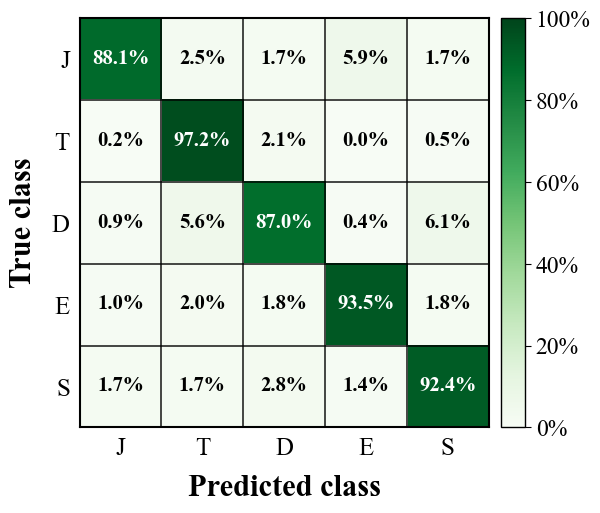

In [51]:
evaluate(
    test1_loader,
    test1_df,
    "Test1_Years21_22_23_Rband_5Classes"
)


Test2_Year24_Rband_5Classes
   Accuracy  MacroPrecision  MacroRecall   MacroF1  NumberOfImages  \
0  0.595688        0.580169     0.559674  0.540618            2644   

   NumberOfGroups  
0            2644  
Accuracy: 0.595688
Macro Precision: 0.580169
Macro Recall: 0.559674
Macro F1 score: 0.540618

Confusion matrix (counts)
[[373 102  52  60  18]
 [ 10 593  24   1  12]
 [ 30 132 166   3  23]
 [137 112 128  66  15]
 [116  48  41   5 377]]

Row-normalized confusion matrix (0-1)
        Predicted_J  Predicted_T  Predicted_D  Predicted_E  Predicted_S
True_J     0.616529     0.168595     0.085950     0.099174     0.029752
True_T     0.015625     0.926562     0.037500     0.001563     0.018750
True_D     0.084746     0.372881     0.468927     0.008475     0.064972
True_E     0.299127     0.244541     0.279476     0.144105     0.032751
True_S     0.197615     0.081772     0.069847     0.008518     0.642249


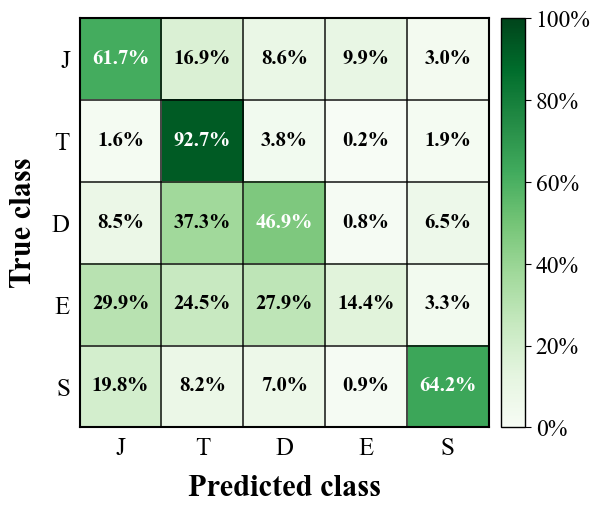

In [52]:

evaluate(
    test2_loader,
    test2_df,
    "Test2_Year24_Rband_5Classes"
)

## Plot training loss

Number of loss points plotted: 20
Epochs plotted: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


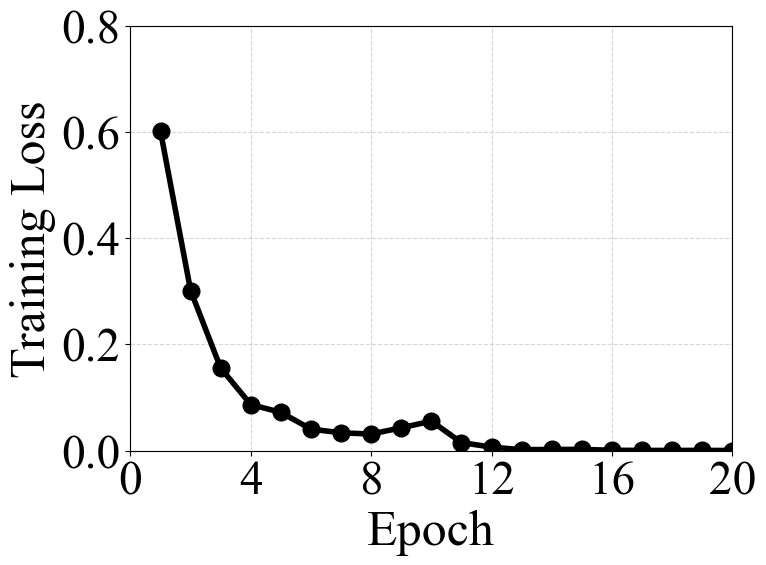

In [54]:
############################################################
# Plot training loss
############################################################

# Explicitly extract all epoch-loss pairs generated during training.
# This guarantees that all 20 epochs are used in the figure.
loss_plot_df = (
    history_df[
        [
            "Epoch",
            "Loss",
        ]
    ]
    .dropna()
    .sort_values(
        by="Epoch"
    )
    .reset_index(
        drop=True
    )
)


# The experiment is configured for 20 epochs, so the history
# must contain exactly 20 valid loss values before plotting.
if len(loss_plot_df) != EPOCHS:

    raise RuntimeError(
        f"Training-loss history contains {len(loss_plot_df)} valid points, "
        f"but EPOCHS={EPOCHS}. "
        "Run the complete training cell before plotting the loss curve."
    )


epoch_values = loss_plot_df[
    "Epoch"
].to_numpy(
    dtype=np.float64
)


loss_values = loss_plot_df[
    "Loss"
].to_numpy(
    dtype=np.float64
)


print(
    "Number of loss points plotted:",
    len(
        epoch_values
    )
)


print(
    "Epochs plotted:",
    epoch_values.astype(
        int
    ).tolist()
)


plt.figure(
    figsize=(
        8,
        6
    )
)


# Plot every epoch as one circular point and connect all points.
plt.plot(
    epoch_values,
    loss_values,
    color="black",
    linewidth=4,
    linestyle="-",
    marker="o",
    markersize=12,
    markerfacecolor="black",
    markeredgecolor="black",
    label="Training Loss"
)


############################################################
# X-axis settings
############################################################

plt.xlim(
    0,
    20
)


plt.xticks(
    np.arange(
        0,
        21,
        4
    ),
    fontsize=34
)


############################################################
# Y-axis settings
############################################################

plt.ylim(
    0,
    0.8
)


plt.yticks(
    np.arange(
        0,
        0.801,
        0.2
    ),
    fontsize=34
)


############################################################
# Labels
############################################################

plt.xlabel(
    "Epoch",
    fontsize=36
)


plt.ylabel(
    "Training Loss",
    fontsize=36
)


############################################################
# Grid
############################################################

plt.grid(
    True,
    linestyle="--",
    alpha=0.5
)


############################################################
# Tight layout
############################################################

plt.tight_layout()


############################################################
# Save figure
############################################################

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "Training_Loss.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)


############################################################
# Show figure
############################################################

plt.show()


plt.close()


## Save final loaded best model

In [56]:
torch.save(
    model.state_dict(),
    os.path.join(
        OUTPUT_DIR,
        "ResNet18_Rband_5Classes_Years21_22_23_Train_Year24_Test_Final.pth"
    )
)


print("\nFinished")

print(
    "All models, CSV files, and figures were saved to:",
    OUTPUT_DIR
)


Finished
All models, CSV files, and figures were saved to: Results_Years21_22_23_TrainTest1_Year24_Test2_RBand_5Classes_ResNet18_Last8Layers
